In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, colors

ur = 0.999994
u0 = 1.26 * 10 ** -6
cu = 1.68 * 10 ** -8
cu_annel = 1.72 * 10 ** -8
al = 2.79 * 10 ** -8
pi = np.pi
ita = 0.785


# Frequency
def_freq = 200 * 10 ** 3

In [83]:
def skin_depth(f):
    return 7.6/np.sqrt(f)/100 # in meters for 20deg c, use 7.6 for 100deg c

print(f"at 100khz,20deg c it should be around 0.0208cm :{skin_depth(100*10**3)}")

at 100khz,20deg c it should be around 0.0208cm :0.0002403331021727968


In [84]:
def coth(x):
        if np.tanh(x) == 0:
            print("divide by 0 err(x is too close to 0!)")
            return np.inf
        
        return 1/np.tanh(x)
print(f"test coth, coth(2) = (should be around 1.0373) :{coth(2)}")

test coth, coth(2) = (should be around 1.0373) :1.0373147207275482


In [85]:
def proximity_effect(f, D, sigma , layer,i = 0,j = 0):
    
    omega = 2*pi*f

    alpha = np.power(((0+1j) * omega * u0 / sigma * ita ) , 0.5)

    print(alpha*D)
    
    if alpha==0:
        print(f"i = {i}")
        print(f"j = {j}")
        return 1 

    ## if alpha -> 0 then tanh(alpha) -> 0, coth(alpha) -> +/-inf

    k = (alpha * D / np.tanh(alpha * D)).real 

    ## then this become +inf

    k += (layer * layer - 1)/3 * ((2 * alpha * D * np.tanh(alpha * D/2)).real )

    ## then this become 0

    ## so the whole formula become +inf*0 (indefinite) 
    ## in any case this only happened when the alpha is very small
    ## which means the effect is very small and the k is extremely close to 1
    return k

print(f"Example calc: proximity_effect(K) {proximity_effect(def_freq,4.4*10**-4,cu_annel,1,0,0)}")

(2.6448344196945195+2.6448344196945195j)
Example calc: proximity_effect(K) 2.636860748738192


In [87]:

# Diameters
diameters = np.logspace(np.log10(skin_depth(def_freq)*0.1),
                        np.log10(skin_depth(def_freq)*20),25)
diameters



array([1.69941166e-05, 2.11921415e-05, 2.64271965e-05, 3.29554574e-05,
       4.10963824e-05, 5.12483448e-05, 6.39081276e-05, 7.96952327e-05,
       9.93821969e-05, 1.23932395e-04, 1.54547183e-04, 1.92724684e-04,
       2.40333102e-04, 2.99702139e-04, 3.73736997e-04, 4.66060548e-04,
       5.81190613e-04, 7.24761043e-04, 9.03797407e-04, 1.12706079e-03,
       1.40547651e-03, 1.75266874e-03, 2.18562722e-03, 2.72553862e-03,
       3.39882333e-03])

In [88]:
# list of possible layers
layers = np.array([0.5,1,2,3,4,5,6,8,10,15,20,30,40,60,80,100,150,200,300], dtype=float)
layers

array([  0.5,   1. ,   2. ,   3. ,   4. ,   5. ,   6. ,   8. ,  10. ,
        15. ,  20. ,  30. ,  40. ,  60. ,  80. , 100. , 150. , 200. ,
       300. ])

In [89]:
results = []
results

[]

['a']

In [91]:
for i, layer in enumerate(layers):
    temp = []
    for j, dia in enumerate(diameters):
        temp.append(proximity_effect(def_freq, dia, cu_annel, layer, i , j))

    results.append(temp)
    

for i in results:
    print(i)

(0.10215141952881356+0.10215141952881356j)
(0.12738569354742713+0.12738569354742713j)
(0.15885354305802718+0.15885354305802718j)
(0.19809483655002028+0.19809483655002028j)
(0.24702983334432022+0.24702983334432022j)
(0.30805315082866175+0.30805315082866175j)
(0.38415094424322216+0.38415094424322216j)
(0.47904703316940994+0.47904703316940994j)
(0.5973851253717497+0.5973851253717497j)
(0.7449560550544498+0.7449560550544498j)
(0.9289811553592668+0.9289811553592668j)
(1.1584656318412758+1.1584656318412758j)
(1.4446392291331198+1.4446392291331198j)
(1.8015057546707431+1.8015057546707431j)
(2.246528350236807+2.246528350236807j)
(2.801484044851202+2.801484044851202j)
(3.493529406263031+3.493529406263031j)
(4.356529438336585+4.356529438336585j)
(5.432714753471954+5.432714753471954j)
(6.774748113227735+6.774748113227735j)
(8.44830146260681+8.44830146260681j)
(10.535269564299611+10.535269564299611j)
(13.137777490981026+13.137777490981026j)
(16.38317808093049+16.38317808093049j)
(20.43028390576271

In [94]:
print(diameters)

[1.69941166e-05 2.11921415e-05 2.64271965e-05 3.29554574e-05
 4.10963824e-05 5.12483448e-05 6.39081276e-05 7.96952327e-05
 9.93821969e-05 1.23932395e-04 1.54547183e-04 1.92724684e-04
 2.40333102e-04 2.99702139e-04 3.73736997e-04 4.66060548e-04
 5.81190613e-04 7.24761043e-04 9.03797407e-04 1.12706079e-03
 1.40547651e-03 1.75266874e-03 2.18562722e-03 2.72553862e-03
 3.39882333e-03]


In [95]:
for i in results:
    print(i)

[np.float64(1.0000006049298384), np.float64(1.0000014628838534), np.float64(1.0000035376467087), np.float64(1.0000085549706683), np.float64(1.0000206881313933), np.float64(1.0000500288827099), np.float64(1.000120979726118), np.float64(1.0002925402727287), np.float64(1.0007073159417665), np.float64(1.0017097467415654), np.float64(1.0041303396572872), np.float64(1.0099632792463191), np.float64(1.023949032720883), np.float64(1.057086417721301), np.float64(1.1334489547797566), np.float64(1.2988388026525894), np.float64(1.6149089026224748), np.float64(2.1063770801695356), np.float64(2.7140564900072217), np.float64(3.39786117793237), np.float64(4.224636409215356), np.float64(5.267259477284269), np.float64(6.5689245018220594), np.float64(8.191587273826768), np.float64(10.21514197999316)]
[np.float64(1.0000096788397739), np.float64(1.0000234059215347), np.float64(1.000056601060122), np.float64(1.0001368720032797), np.float64(1.0003309660859034), np.float64(1.0008002047730247), np.float64(1.001

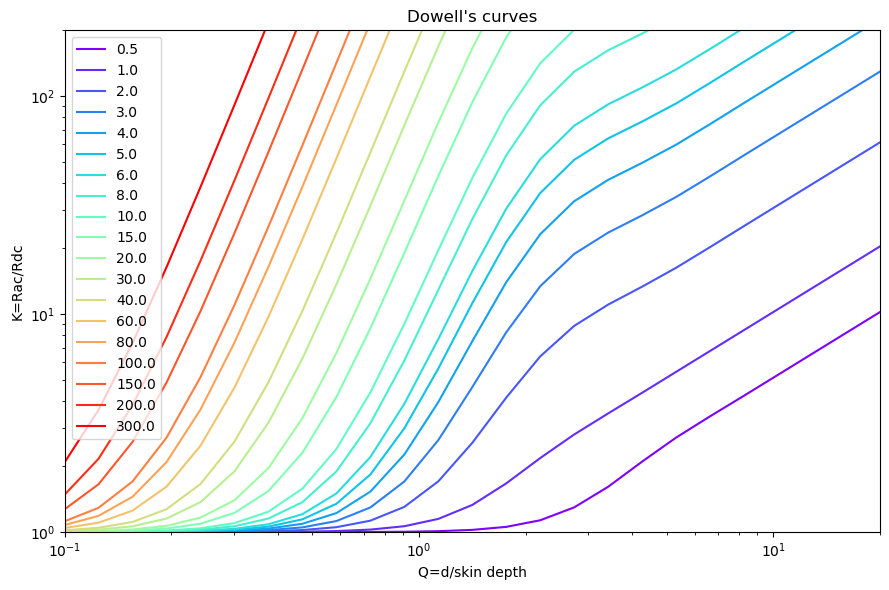

In [98]:
# Plot
plt.figure(figsize=(9, 6))


# Color map
colors = plt.cm.rainbow(np.linspace(0, 1, len(layers)))
# plt.colorbar(colors, label='Layers')


# Plot only the valid portion
for i, layer in enumerate(layers):
    plt.plot(diameters/skin_depth(def_freq), results[i],
         linestyle='solid', color=colors[i], label=layer)
# No legends for skin depth line

# Range
plt.xlim([0.1,20])
plt.ylim([1,200])
# Log scales
plt.xscale('log')
plt.yscale('log')

# Adding legend
plt.legend()

# Labels and title
plt.xlabel('Q=d/skin depth')
plt.ylabel('K=Rac/Rdc')
plt.title('Dowell\'s curves')
plt.tight_layout()
plt.show()